In [54]:
import os, sys, torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score,
                             precision_recall_fscore_support)
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.combined_model import CombinedRoberta
from src.mtl_model import RobertaMTL
from src.rs_model import RationaleSupervisedRoberta
from src.baseline_model import RobertaBaseline 
from src.config import DEVICE, MODEL_NAME   
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']
LABEL_MAP   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
SEEDS       = [7, 42, 100]
MODEL_ORDER = ['Baseline', 'MTL', 'RS', 'Combined']
COLORS      = {'Baseline': '#4e79a7', 'MTL': '#f28e2b', 'RS': '#e15759', 'Combined': '#59a14f'}

os.makedirs('../outputs/figures', exist_ok=True)
PRED_DIR = '../outputs/predictions'
os.makedirs(PRED_DIR, exist_ok=True)

## 1. Run predictions on test and golden set

In [55]:
# Load best models

MODEL_PATHS = {
    'Baseline': {s: os.path.join(parent_dir, f'models/baseline_models/baseline_seed{s}.pt') 
                 for s in SEEDS},
    'MTL':      {s: os.path.join(parent_dir, f'models/mtl_models/tuned_mtl_seed{s}_lam0.2.pt')
                 for s in SEEDS},
    'RS':       {s: os.path.join(parent_dir, f'models/rs_models/rs_seed{s}_lam0.1.pt')
                 for s in SEEDS},
    'Combined': {s: os.path.join(parent_dir, f'models/combined_models/comb_seed{s}_lam0.2.pt')
                 for s in SEEDS},
}

def load_model(model_name, seed):
    config = AutoConfig.from_pretrained(MODEL_NAME)
    path   = MODEL_PATHS[model_name][seed]

    if model_name == 'Baseline':
        model = RobertaBaseline(MODEL_NAME, config, dropout_prob=0.1)
        model.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
    elif model_name == 'MTL':
        model = RobertaMTL(MODEL_NAME, config, dropout_prob=0.15)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
    elif model_name == 'RS':
        model = RationaleSupervisedRoberta(MODEL_NAME, config, dropout_prob=0.1)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
    elif model_name == 'Combined':
        model = CombinedRoberta(MODEL_NAME, config, dropout_prob=0.1)
        model.load_state_dict(torch.load(path, map_location=DEVICE))

    return model.to(DEVICE).eval()


def run_inference(model, model_name, tokenizer, texts, batch_size=32):
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch  = texts[i:i+batch_size]
            inputs = tokenizer(batch, return_tensors='pt', truncation=True,
                               padding=True, max_length=128).to(DEVICE)
            if model_name == 'Baseline':
                logits = model(**inputs).logits
            elif model_name == 'MTL':
                logits = model(inputs['input_ids'], inputs['attention_mask'],
                               task='sentiment').logits
            elif model_name == 'RS':
                out, _ = model(inputs['input_ids'], inputs['attention_mask'])
                logits  = out.logits
            elif model_name == 'Combined':
                out, _ = model(inputs['input_ids'], inputs['attention_mask'],
                               task='sentiment')
                logits  = out.logits
            all_probs.append(F.softmax(logits, dim=-1).cpu().numpy())

    probs = np.vstack(all_probs)
    return probs.argmax(axis=1), probs


def run_sarcasm_inference(model, tokenizer, texts, batch_size=32):
    all_preds = []
    model.eval()
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, return_tensors='pt', padding=True, 
                               truncation=True, max_length=128).to(DEVICE)
            
            # Handle Combined Model
            if isinstance(model, CombinedRoberta):
                out, _ = model(inputs['input_ids'], inputs['attention_mask'], task='sarcasm')
                logits = out.logits
            elif isinstance(model, RobertaMTL):
                # Ensure your MTL model handles the task argument or use the correct index
                logits = model(inputs['input_ids'], inputs['attention_mask'], task='sarcasm').logits
            else:
                # Baseline or RS usually don't have a 'sarcasm' head unless specifically trained
                outputs = model(inputs['input_ids'], inputs['attention_mask'])
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs[0]

            # 3. Convert raw logits to 0 or 1 labels
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            
            
    return np.array(all_preds)

In [56]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

df_test_raw = pd.read_csv(os.path.join(parent_dir, 'data/raw/sentiment_test.csv'))
df_gold_raw = pd.read_csv(os.path.join(parent_dir, 'data/processed/golden_set_clean.csv'))

RESULTS_CSV = f'{PRED_DIR}/all_results.csv'
FORCE_RERUN = False

def compute_metrics(y_true, y_pred, probs, prefix):
    """Compute macro metrics + per-class F1."""
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred,
                                                   average='macro', zero_division=0)
    class_f1s = f1_score(y_true, y_pred, average=None, zero_division=0)
    return {
        f'{prefix} F1':     round(f1_score(y_true, y_pred, average='macro'), 4),
        f'{prefix} Acc':    round(accuracy_score(y_true, y_pred), 4),
        f'{prefix} Prec':   round(p, 4),
        f'{prefix} Recall': round(r, 4),
        f'{prefix} F1_Neg': round(class_f1s[0], 4),
        f'{prefix} F1_Neu': round(class_f1s[1], 4),
        f'{prefix} F1_Pos': round(class_f1s[2], 4),
    }

if os.path.exists(RESULTS_CSV) and not FORCE_RERUN:
    print(f'Loading existing results from {RESULTS_CSV}')
    df_seeds = pd.read_csv(RESULTS_CSV)
else:
    records = []
    for model_name in MODEL_ORDER:
        for seed in SEEDS:
            print(f'  {model_name} | Seed {seed}')
            model = load_model(model_name, seed)

            preds_t, probs_t = run_inference(model, model_name, tokenizer, 
                                              df_test_raw['text'].tolist())
            preds_g, probs_g = run_inference(model, model_name, tokenizer, 
                                              df_gold_raw['text'].tolist())

            # Save Test Set Predictions
            df_t_out = df_test_raw.copy()
            df_t_out['pred'] = preds_t
            df_t_out['confidence'] = probs_t.max(axis=1)
            df_t_out.to_csv(f'{PRED_DIR}/{model_name.lower()}_seed{seed}_test.csv', index=False)

            # Save Gold Set Predictions
            df_g_out = df_gold_raw.copy()
            df_g_out['pred'] = preds_g
            df_g_out['confidence'] = probs_g.max(axis=1)

            # Keep sarcasm inference for MTL
            if model_name == 'MTL' or model_name == 'Combined':
                df_g_out['pred_sarcasm'] = run_sarcasm_inference(
                    model, tokenizer, df_gold_raw['text'].tolist())

            df_g_out.to_csv(f'{PRED_DIR}/{model_name.lower()}_seed{seed}_gold.csv', index=False)

            t_metrics = compute_metrics(df_test_raw['label'].values, preds_t, probs_t, 'Test')
            g_metrics = compute_metrics(df_gold_raw['label'].values, preds_g, probs_g, 'Gold')
            records.append({'Model': model_name, 'Seed': seed, **t_metrics, **g_metrics})

            del model
            torch.cuda.empty_cache()

    df_seeds = pd.DataFrame(records)
    df_seeds.to_csv(RESULTS_CSV, index=False)
    print(f'Saved all results into {RESULTS_CSV}')

print(df_seeds[['Model','Seed','Test F1','Gold F1']].to_string(index=False))

Loading existing results from ../outputs/predictions/all_results.csv
   Model  Seed  Test F1  Gold F1
Baseline     7   0.7181   0.5126
Baseline    42   0.7162   0.5690
Baseline   100   0.7211   0.5878
     MTL     7   0.7125   0.6654
     MTL    42   0.7185   0.6230
     MTL   100   0.7164   0.6402
      RS     7   0.7174   0.7108
      RS    42   0.7123   0.6998
      RS   100   0.7260   0.6925
Combined     7   0.7099   0.7687
Combined    42   0.7158   0.6830
Combined   100   0.7155   0.7215


## 2. Quantitative analysis 

Note: For Quantitative analysis, we will report aggerated 3-seed results 

### Performance Summary

In [105]:
agg = df_seeds.groupby('Model')[['Test F1','Test Acc','Gold F1','Gold Acc']].agg(['mean','std'])
agg.columns = [' '.join(c) for c in agg.columns]
agg = agg.loc[MODEL_ORDER].round(4)
print('Performance Summary (mean ± std over 3 seeds)\n')
print(agg.to_string())

Performance Summary (mean ± std over 3 seeds)

          Test F1 mean  Test F1 std  Test Acc mean  Test Acc std  Gold F1 mean  Gold F1 std  Gold Acc mean  Gold Acc std
Model                                                                                                                   
Baseline        0.7185       0.0025         0.7174        0.0027        0.5565       0.0391         0.5814        0.0308
MTL             0.7158       0.0030         0.7143        0.0033        0.6429       0.0213         0.6473        0.0135
RS              0.7186       0.0069         0.7193        0.0082        0.7010       0.0092         0.7054        0.0067
Combined        0.7137       0.0033         0.7127        0.0035        0.7244       0.0429         0.7248        0.0408


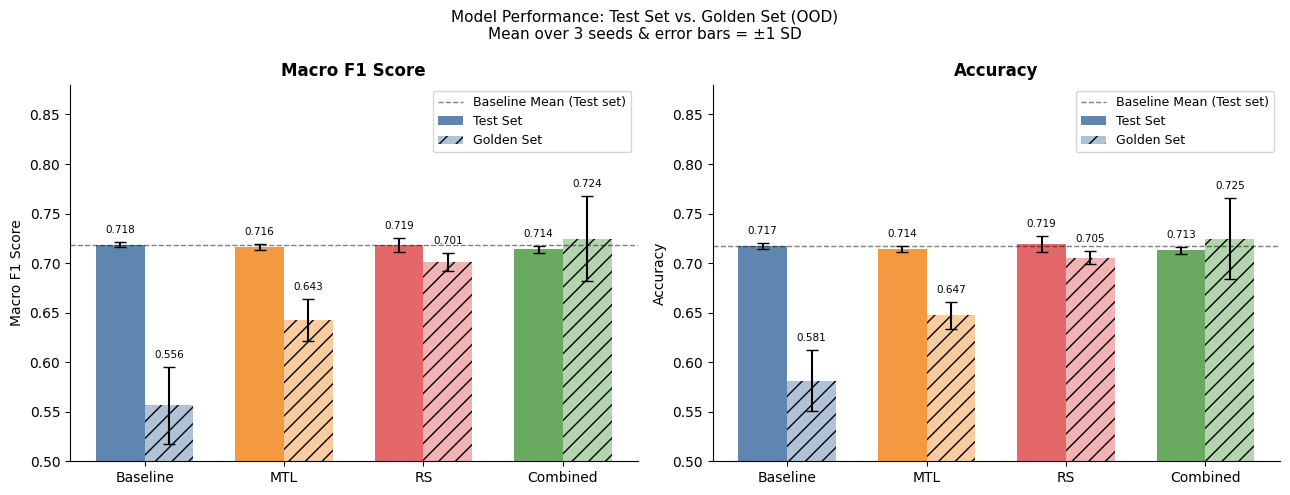

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x     = np.arange(len(MODEL_ORDER))
width = 0.35

for ax, t_col, g_col, ylabel in [
    (axes[0], 'Test F1',  'Gold F1',  'Macro F1 Score'),
    (axes[1], 'Test Acc', 'Gold Acc', 'Accuracy'),
]:
    t_means = [df_seeds[df_seeds['Model']==m][t_col].mean() for m in MODEL_ORDER]
    g_means = [df_seeds[df_seeds['Model']==m][g_col].mean() for m in MODEL_ORDER]
    t_stds  = [df_seeds[df_seeds['Model']==m][t_col].std()  for m in MODEL_ORDER]
    g_stds  = [df_seeds[df_seeds['Model']==m][g_col].std()  for m in MODEL_ORDER]
    bar_colors = [COLORS[m] for m in MODEL_ORDER]

    bars1 = ax.bar(x - width/2, t_means, width, yerr=t_stds, capsize=4,
                   color=bar_colors, alpha=0.9, label='Test Set',
                   error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
    bars2 = ax.bar(x + width/2, g_means, width, yerr=g_stds, capsize=4,
                   color=bar_colors, alpha=0.45, label='Golden Set', hatch='//',
                   error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
    baseline_val = df_seeds[df_seeds['Model']=='Baseline'][t_col].mean()
    ax.axhline(baseline_val, color='black', linestyle='--', linewidth=1, 
               alpha=0.5, label='Baseline Mean (Test set)', zorder=2)
    for bar, m, s in zip(bars1, t_means, t_stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.007,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7.5)
    for bar, m, s in zip(bars2, g_means, g_stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.007,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.50, 0.88)
    ax.set_title(ylabel, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Model Performance: Test Set vs. Golden Set (OOD)\n'
    'Mean over 3 seeds & error bars = ±1 SD',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../outputs/figures/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Generalization gap

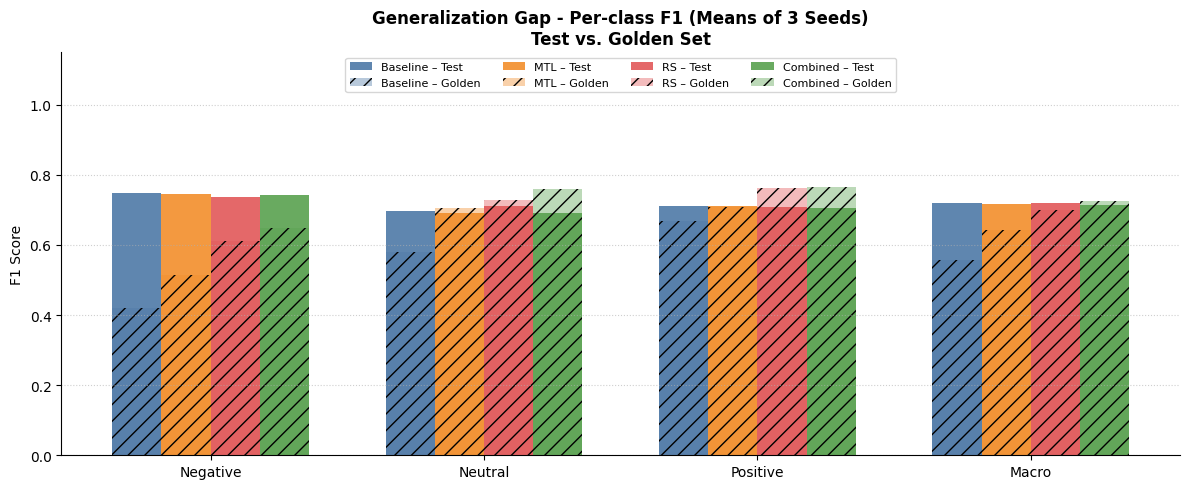

In [107]:
# Generalization Gap Plot
def get_all_f1s(y_true, y_pred):
    per_c = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    return list(per_c) + [f1_score(y_true, y_pred, average='macro')]

classes_ext = LABEL_NAMES + ['Macro']
test_cols = ['Test F1_Neg', 'Test F1_Neu', 'Test F1_Pos', 'Test F1']
gold_cols = ['Gold F1_Neg', 'Gold F1_Neu', 'Gold F1_Pos', 'Gold F1']

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(classes_ext))
width = 0.18

for i, model_name in enumerate(MODEL_ORDER):
    model_df = df_seeds[df_seeds['Model'] == model_name]
    tf1s = [model_df[col].mean() for col in test_cols]
    gf1s = [model_df[col].mean() for col in gold_cols]
    
    offset = (i - 1.5) * width
    color  = COLORS[model_name]
    
    # Plotting Test Set (Solid)
    ax.bar(x + offset, tf1s, width, color=color, alpha=0.9,
           label=f'{model_name} – Test')
    
    # Plotting Golden Set (Hatched)
    ax.bar(x + offset, gf1s, width, color=color, alpha=0.4,
           hatch='//', label=f'{model_name} – Golden')

ax.set_xticks(x)
ax.set_xticklabels(classes_ext)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15) # Room for legend
ax.set_title('Generalization Gap - Per-class F1 (Means of 3 Seeds)\n'
            'Test vs. Golden Set', fontweight='bold')

ax.legend(ncol=4, fontsize=8, loc='upper center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/figures/generalization_gap_means.png', dpi=300, bbox_inches='tight')
plt.show()

### Confusion matrices

In [108]:
# Classification Report
for split, split_label in [('test', 'Test Set'), ('gold', 'Golden Set (OOD)')]:
    print(f'\n{split_label} (Aggregated: Seeds 7, 42, 100)')
    print(f'{"="*65}')
    
    for model_name in MODEL_ORDER:
        all_labels = []
        all_preds = []
        
        # Collect predictions from all seeds
        for seed in [7, 42, 100]:
            try:
                df_ = pd.read_csv(f'{PRED_DIR}/{model_name.lower()}_seed{seed}_{split}.csv')
                all_labels.extend(df_['label'].tolist())
                all_preds.extend(df_['pred'].tolist())
            except FileNotFoundError:
                continue
        
        print(f'\n── {model_name} ──')
        if all_labels:
            print(classification_report(all_labels, all_preds,
                                        target_names=LABEL_NAMES, digits=4))


Test Set (Aggregated: Seeds 7, 42, 100)

── Baseline ──
              precision    recall  f1-score   support

    Negative     0.7031    0.7977    0.7474     11916
     Neutral     0.7575    0.6459    0.6973     17811
    Positive     0.6661    0.7617    0.7107      7125

    accuracy                         0.7174     36852
   macro avg     0.7089    0.7351    0.7185     36852
weighted avg     0.7223    0.7174    0.7161     36852


── MTL ──
              precision    recall  f1-score   support

    Negative     0.6943    0.8032    0.7448     11916
     Neutral     0.7570    0.6373    0.6920     17811
    Positive     0.6689    0.7579    0.7106      7125

    accuracy                         0.7143     36852
   macro avg     0.7067    0.7328    0.7158     36852
weighted avg     0.7197    0.7143    0.7127     36852


── RS ──
              precision    recall  f1-score   support

    Negative     0.7236    0.7498    0.7365     11916
     Neutral     0.7337    0.6924    0.7125     178

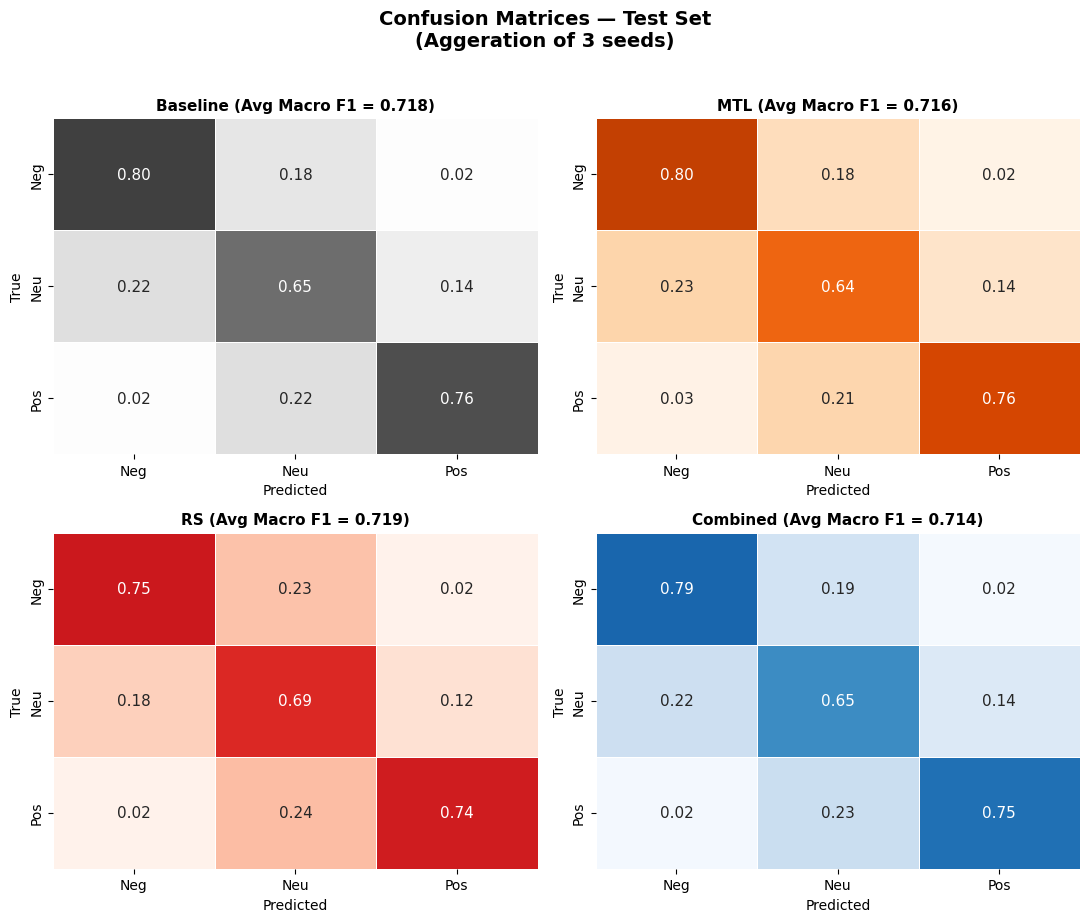

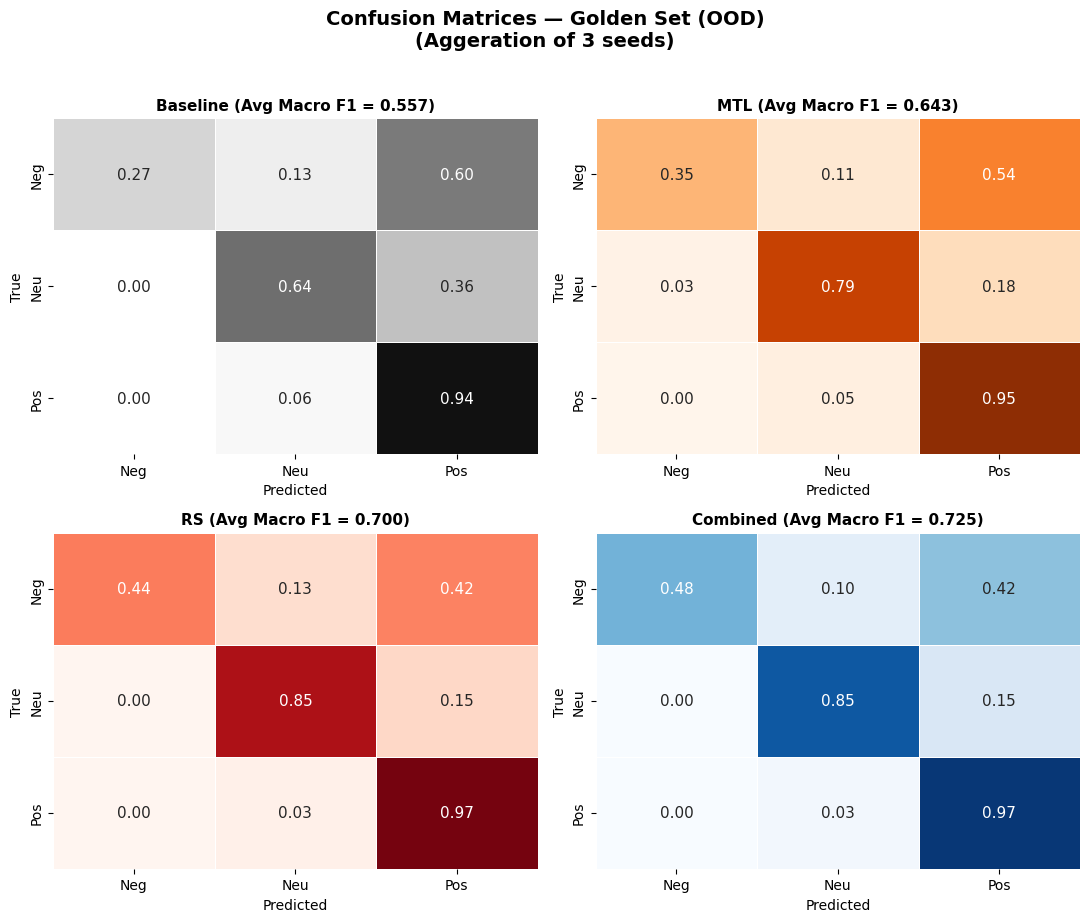

In [109]:
# Aggregated Confusion Matrices (3 Seeds)
for split, split_label in [('test', 'Test Set'), ('gold', 'Golden Set (OOD)')]:
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    cmaps = ['Greys', 'Oranges', 'Reds', 'Blues']

    for ax, model_name, cmap in zip(axes.flat, MODEL_ORDER, cmaps):
        all_labels = []
        all_preds = []
        
        # 1. Accumulate data from all seeds
        for seed in [7, 42, 100]:
            try:
                df_ = pd.read_csv(f'{PRED_DIR}/{model_name.lower()}_seed{seed}_{split}.csv')
                all_labels.extend(df_['label'].tolist())
                all_preds.extend(df_['pred'].tolist())
            except FileNotFoundError:
                continue
        
        # 2. Calculate confusion matrix on aggregated data
        # 'true' normalization is best as it shows Recall per class
        cm = confusion_matrix(all_labels, all_preds, normalize='true')
        
        # 3. Calculate Macro F1 on aggregated data
        mf1 = f1_score(all_labels, all_preds, average='macro')

        sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, ax=ax,
                    xticklabels=['Neg','Neu','Pos'],
                    yticklabels=['Neg','Neu','Pos'],
                    vmin=0, vmax=1, linewidths=0.5, cbar=False,
                    annot_kws={'size': 11})
        
        # Note the "Avg" in the title to be precise for your thesis
        ax.set_title(f'{model_name} (Avg Macro F1 = {mf1:.3f})',
                    fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    fig.suptitle(
        f'Confusion Matrices — {split_label}\n(Aggeration of 3 seeds)',
        fontsize=14, y=1.02, fontweight='bold'
    )
    
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/confusion_matrices_{split}.png',
                dpi=300, bbox_inches='tight') # Increased DPI for better thesis quality
    plt.show()

### Statistical significance tests

In [125]:
# Statistical test: McNemar's Test (with Median P-Value Aggregation)
def mcnemar_test(correct_a, correct_b):
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    if b + c == 0:
        return 1.0, b, c 
    # Edwards continuity correction
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    return stats.chi2.sf(chi2, df=1), b, c

pairs = [('MTL','Baseline'), ('RS','Baseline'), ('Combined','Baseline'),
         ('Combined','MTL'), ('Combined','RS')]

seeds = [7, 42, 100]
rows = []

for dataset_label, split in [('Test Set','test'), ('Golden Set','gold')]:
    for model_a, model_b in pairs:
        seed_p_values = []
        seed_rescues = []
        seed_regressions = []
        
        for seed in seeds:
            try:
                df_a = pd.read_csv(f'{PRED_DIR}/{model_a.lower()}_seed{seed}_{split}.csv')
                df_b = pd.read_csv(f'{PRED_DIR}/{model_b.lower()}_seed{seed}_{split}.csv')
                
                ca = (df_a['label'].values == df_a['pred'].values)
                cb = (df_b['label'].values == df_b['pred'].values)
                
                p, b, c = mcnemar_test(ca, cb)
                seed_p_values.append(p)
                seed_rescues.append(b)
                seed_regressions.append(c)
            except FileNotFoundError:
                continue

        if not seed_p_values:
            continue

        # Aggregate by taking the mediann of p-values
        med_p = np.median(seed_p_values)
        med_rescues = np.median(seed_rescues)
        med_regs = np.median(seed_regressions)

        rows.append({
            'Dataset':     dataset_label,
            'Model A':     model_a,
            'vs. Model B': model_b, 
            'Rescues*':    round(med_rescues), 
            'Regressions*': round(med_regs),
            'Net*':        round(med_rescues - med_regs),
            'p-value':     med_p,
            'Sig. (α=.05)': '✓' if med_p < 0.05 else '✗',
        })

df_mcnemar = pd.DataFrame(rows)

# Display results
for dataset in ['Test Set', 'Golden Set']:
    print(f"\nMcNemar's Test — {dataset} (Aggregated: Seeds 7, 42, 100)")
    print(f'{"─"*75}')
    sub = df_mcnemar[df_mcnemar['Dataset']==dataset].drop(columns='Dataset')
    sub['p-value'] = sub['p-value'].apply(lambda x: f"{x:.4f}" if x >= 0.0001 else "<0.001")
    print(sub.to_string(index=False))

print('\nNote: Rescues = Model A correct & Model B wrong. Regressions = Model A wrong & Model B correct.')
print('Net = Rescues - Regressions')



McNemar's Test — Test Set (Aggregated: Seeds 7, 42, 100)
───────────────────────────────────────────────────────────────────────────
 Model A vs. Model B  Rescues*  Regressions*  Net* p-value Sig. (α=.05)
     MTL    Baseline       363           423   -60  0.0294            ✓
      RS    Baseline       449           404    45  0.1198            ✗
Combined    Baseline       435           479   -44  0.0295            ✓
Combined         MTL       389           393    -4  0.4177            ✗
Combined          RS       459           574  -115  0.0007            ✓

McNemar's Test — Golden Set (Aggregated: Seeds 7, 42, 100)
───────────────────────────────────────────────────────────────────────────
 Model A vs. Model B  Rescues*  Regressions*  Net* p-value Sig. (α=.05)
     MTL    Baseline         5             1     4  0.2207            ✗
      RS    Baseline         9             0     9  0.0077            ✓
Combined    Baseline        10             0    10  0.0044            ✓
Combined  

## 3. Error Analysis

### Error taxonomy

In [111]:
# Error Taxonomy
def error_taxonomy(df):
    errors = df[df['label'] != df['pred']].copy()
    polarity = errors[
        ((errors['label']==0) & (errors['pred']==2)) |
        ((errors['label']==2) & (errors['pred']==0))
    ]
    under = errors[(errors['label'].isin([0,2])) & (errors['pred']==1)]
    over_ = errors[(errors['label']==1) & (errors['pred'].isin([0,2]))]
    return len(errors), len(polarity), len(under), len(over_)

def cohen_h(p1, p2):
    return 2*np.arcsin(np.sqrt(max(p1,1e-9))) - 2*np.arcsin(np.sqrt(max(p2,1e-9)))

# Compute for both splits using mean across seeds
tax_rows = []
seeds = [7, 42, 100]

for dataset, split in [('Test Set','test'), ('Golden Set','gold')]:
    # We calculate the mean for each model first
    for model_name in MODEL_ORDER:
        seed_stats = []
        
        for seed in seeds:
            try:
                df_ = pd.read_csv(f'{PRED_DIR}/{model_name.lower()}_seed{seed}_{split}.csv')
                N = len(df_)
                n_err, n_pol, n_und, n_ov = error_taxonomy(df_)
                seed_stats.append([n_err/N, n_pol/N, n_und/N, n_ov/N])
            except FileNotFoundError:
                continue
        
        if not seed_stats: continue
        
        # Mean proportions across all seeds
        avg_err, avg_pol, avg_und, avg_ov = np.mean(seed_stats, axis=0)
        
        tax_rows.append({
            'Dataset': dataset, 
            'Model': model_name,
            'Error Rate': round(avg_err, 4),
            'Polarity Flip Rate': round(avg_pol, 4),
            'Under-sensitive': round(avg_und, 4),
            'Over-sensitive': round(avg_ov, 4)
        })

# Now calculate Cohen's h based on the averaged rates
df_tax = pd.DataFrame(tax_rows)

final_rows = []
for dataset in ['Test Set', 'Golden Set']:
    sub = df_tax[df_tax['Dataset'] == dataset].copy()
    base_flip = sub[sub['Model'] == 'Baseline']['Polarity Flip Rate'].values[0]
    
    for _, row in sub.iterrows():
        h = round(cohen_h(row['Polarity Flip Rate'], base_flip), 4) if row['Model'] != 'Baseline' else '—'
        row_dict = row.to_dict()
        row_dict["Cohen's h (flip)"] = h
        final_rows.append(row_dict)

df_tax = pd.DataFrame(final_rows)

# Print Tables
for dataset in ['Test Set', 'Golden Set']:
    print(f'\n{dataset} (Aggregated Seeds 7, 42, 100):')
    print(df_tax[df_tax['Dataset']==dataset].drop(columns='Dataset').to_string(index=False))
print("\nCohen's h vs Baseline: |h| < 0.2 = small, 0.2–0.5 = medium, > 0.5 = large")


Test Set (Aggregated Seeds 7, 42, 100):
   Model  Error Rate  Polarity Flip Rate  Under-sensitive  Over-sensitive Cohen's h (flip)
Baseline      0.2826              0.0116           0.0999          0.1711                —
     MTL      0.2857              0.0116           0.0989          0.1753              0.0
      RS      0.2807              0.0106           0.1215          0.1486          -0.0095
Combined      0.2873              0.0102           0.1057          0.1714          -0.0135

Golden Set (Aggregated Seeds 7, 42, 100):
   Model  Error Rate  Polarity Flip Rate  Under-sensitive  Over-sensitive Cohen's h (flip)
Baseline      0.4186              0.2791           0.0853          0.0543                —
     MTL      0.3527              0.2519           0.0698          0.0310          -0.0616
      RS      0.2946              0.1977           0.0736          0.0233          -0.1917
Combined      0.2752              0.1938           0.0581          0.0233          -0.2015

Cohen

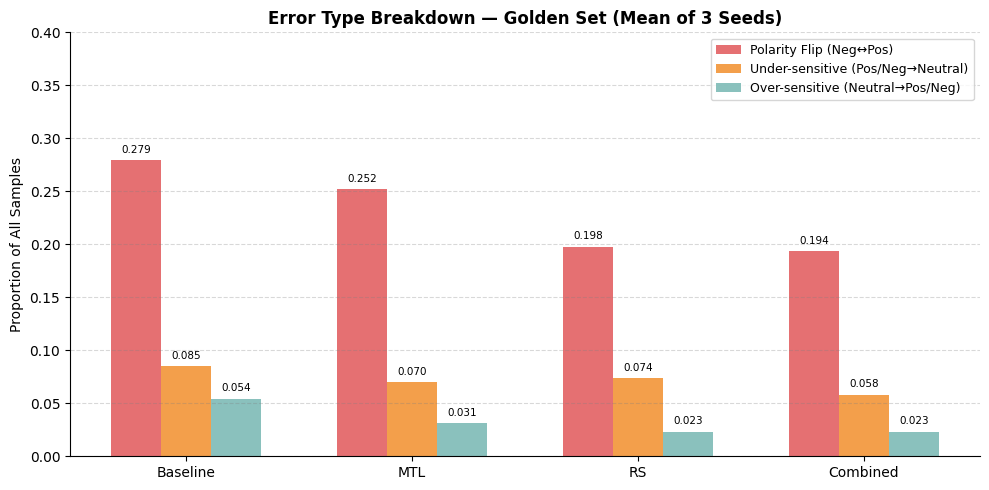

In [112]:
# Bar chart — Golden Set only
df_tax_gold = df_tax[df_tax['Dataset']=='Golden Set'].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(MODEL_ORDER))
width  = 0.22
types  = ['Polarity Flip Rate', 'Under-sensitive', 'Over-sensitive']
colors_err = ['#e15759', '#f28e2b', '#76b7b2']
labels_err = ['Polarity Flip (Neg↔Pos)', 'Under-sensitive (Pos/Neg→Neutral)', 'Over-sensitive (Neutral→Pos/Neg)']

for i, (t, c, lab) in enumerate(zip(types, colors_err, labels_err)):
    offset = (i - 1) * width
    vals   = [df_tax_gold[df_tax_gold['Model']==m][t].values[0] for m in MODEL_ORDER]
    bars   = ax.bar(x + offset, vals, width, label=lab, color=c, alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.grid(axis='y', linestyle='--', alpha=0.3, which='major', color='gray', zorder=0)
ax.set_ylabel('Proportion of All Samples')
ax.set_ylim(0, 0.40)
ax.set_title('Error Type Breakdown — Golden Set (Mean of 3 Seeds)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/error_taxonomy_golden.png', dpi=150, bbox_inches='tight')
plt.show()

### Confidence analysis

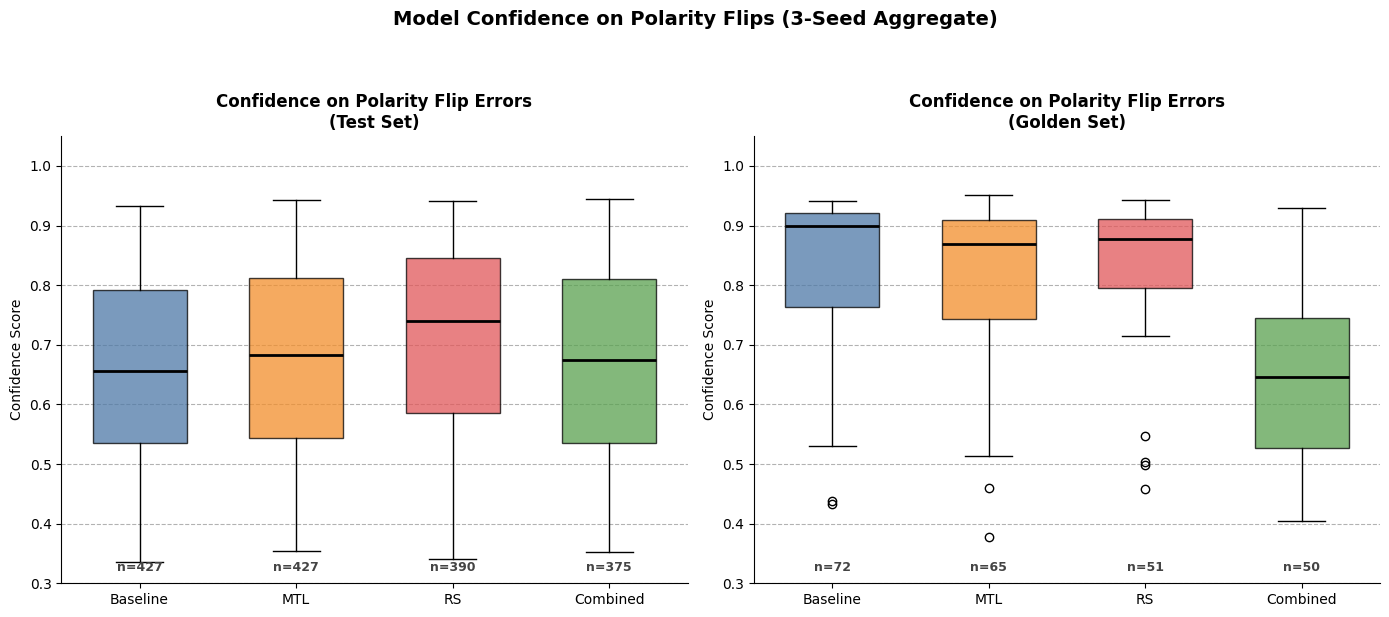

In [26]:
# Confidence Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (split, split_label) in zip(axes, [('test', 'Test Set'), ('gold', 'Golden Set')]):
    flip_confs = {}
    
    for model_name in MODEL_ORDER:
        all_seed_confs = []
        
        # Aggregate data across all 3 seeds
        for seed in SEEDS:
            try:
                df_path = f"{PRED_DIR}/{model_name.lower()}_seed{seed}_{split}.csv"
                df_ = pd.read_csv(df_path)
                
                # Filter for Polarity Flips (Negative <-> Positive)
                # Assumes label 0 = Neg, 2 = Pos
                flips = df_[
                    ((df_['label'] == 0) & (df_['pred'] == 2)) |
                    ((df_['label'] == 2) & (df_['pred'] == 0))
                ]
                
                if not flips.empty:
                    all_seed_confs.extend(flips['confidence'].values)
            except FileNotFoundError:
                continue
                
        if all_seed_confs:
            flip_confs[model_name] = all_seed_confs

    # Plotting Logic
    if flip_confs:
        current_models = [m for m in MODEL_ORDER if m in flip_confs]
        plot_data = [flip_confs[m] for m in current_models]
        
        bp = ax.boxplot(
            plot_data,
            patch_artist=True,
            notch=False,
            medianprops={'color': 'black', 'lw': 2},
            widths=0.6
        )

        # Style boxes with your color scheme
        for patch, m_name in zip(bp['boxes'], current_models):
            patch.set_facecolor(COLORS[m_name])
            patch.set_alpha(0.75)

        # Labels and Y-axis limits
        ax.set_xticks(range(1, len(current_models) + 1))
        ax.set_xticklabels(current_models)
        ax.set_ylabel('Confidence Score')
        ax.set_ylim(0.3, 1.05)
        ax.set_title(f'Confidence on Polarity Flip Errors\n({split_label})', 
                     fontweight='bold', fontsize=12)
        
        ax.grid(axis='y', linestyle='--', alpha=0.6, which='major', color='gray', zorder=0)

        # Annotate aggregated sample sizes (n)
        for i, m in enumerate(current_models, 1):
            n_total = len(flip_confs[m])
            ax.text(i, 0.32, f'n={n_total}', ha='center', fontsize=9, color='#444444', fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# FINAL LAYOUT ---
fig.suptitle(
    'Model Confidence on Polarity Flips (3-Seed Aggregate)\n',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../outputs/figures/flip_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

### Calibration

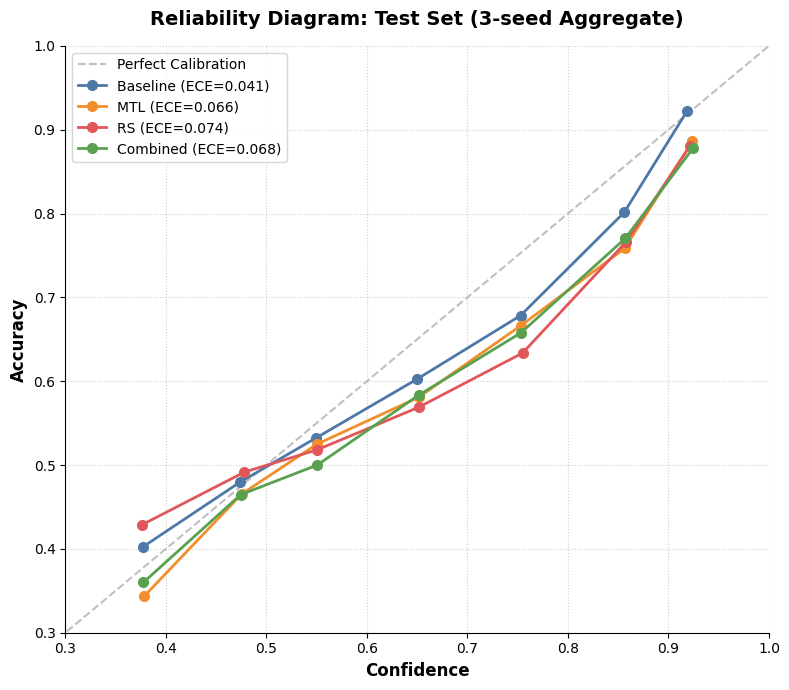

In [40]:
# Reliability Analysis (Model Calibration)
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Perfect Calibration', zorder=1)

for model in MODEL_ORDER:
    confs, correct = [], []
    for seed in SEEDS:
        try:
            df = pd.read_csv(f'{PRED_DIR}/{model.lower()}_seed{seed}_test.csv')
            confs.extend(df['confidence'].values)
            correct.extend((df['pred'] == df['label']).astype(int).values)
        except: continue
    
    confs, correct = np.array(confs), np.array(correct)
    bin_edges = np.linspace(0, 1, 11)
    b_acc, b_conf, b_cnt = [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confs > lo) & (confs <= hi)
        if mask.sum() > 0:
            b_acc.append(correct[mask].mean())
            b_conf.append(confs[mask].mean())
            b_cnt.append(mask.sum())

    ece = np.sum(np.abs(np.array(b_acc) - np.array(b_conf)) * np.array(b_cnt)) / len(correct)

    ax.plot(b_conf, b_acc, 'o-', color=COLORS[model], 
            label=f'{model} (ECE={ece:.3f})', lw=2, markersize=7, zorder=2)

ax.set_xlabel('Confidence', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Reliability Diagram: Test Set (3-seed Aggregate)', fontweight='bold', fontsize=14, pad=15)
ax.set_xlim(0.3, 1.0) # Reset to 0-1 to see the full curve you liked
ax.set_ylim(0.3, 1.0)
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/calibration_test.png', dpi=300, bbox_inches='tight')
plt.show()

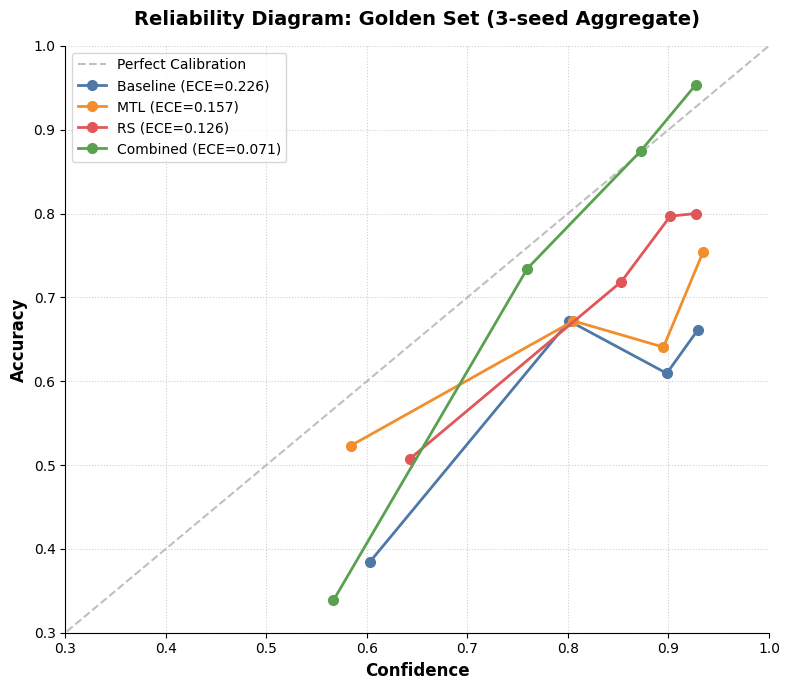

In [39]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Perfect Calibration', zorder=1)

for model in MODEL_ORDER:
    confs, correct = [], []
    for seed in SEEDS:
        try:
            df = pd.read_csv(f'{PRED_DIR}/{model.lower()}_seed{seed}_gold.csv')
            confs.extend(df['confidence'].values)
            correct.extend((df['pred'] == df['label']).astype(int).values)
        except: continue
    
    df_cal = pd.DataFrame({'conf': confs, 'corr': correct})
    df_cal['bin'] = pd.qcut(df_cal['conf'], 4, duplicates='drop')
    
    group = df_cal.groupby('bin', observed=True)
    b_acc = group['corr'].mean()
    b_conf = group['conf'].mean()
    ece = np.sum(np.abs(b_acc - b_conf) * group['corr'].count()) / len(correct)

    ax.plot(b_conf, b_acc, 'o-', color=COLORS[model], 
            label=f'{model} (ECE={ece:.3f})', lw=2, markersize=7, zorder=2)

# Formatting
ax.set_xlabel('Confidence', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Reliability Diagram: Golden Set (3-seed Aggregate)', fontweight='bold', fontsize=14, pad=15)
ax.set_xlim(0.3, 1.0)
ax.set_ylim(0.3, 1.0) 
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/calibration_gold.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Qualitative analysis 

Note: For Qualitative analysis, we will only take 1 seed (seed 7) to analyze

In [8]:
# Integrated Gradients
# Load seed 7 models for Integrated Gradients
ig_models = {}
config_ig = AutoConfig.from_pretrained(MODEL_NAME)

config_ig = AutoConfig.from_pretrained(MODEL_NAME)
ig_models['Baseline'] = RobertaBaseline(MODEL_NAME, config_ig, dropout_prob=0.1).to(DEVICE)
ig_models['Baseline'].load_state_dict(torch.load(MODEL_PATHS['Baseline'][7], map_location=DEVICE, weights_only=True))
ig_models['Baseline'].eval()

ig_models['MTL'] = RobertaMTL(MODEL_NAME, config_ig, dropout_prob=0.15).to(DEVICE)
ig_models['MTL'].load_state_dict(torch.load(MODEL_PATHS['MTL'][7], map_location=DEVICE, weights_only=True))
ig_models['MTL'].eval()

ig_models['RS'] = RationaleSupervisedRoberta(MODEL_NAME, config_ig, dropout_prob=0.1).to(DEVICE)
ig_models['RS'].load_state_dict(torch.load(MODEL_PATHS['RS'][7], map_location=DEVICE, weights_only=True))
ig_models['RS'].eval()

ig_models['Combined'] = CombinedRoberta(MODEL_NAME, config_ig, dropout_prob=0.1).to(DEVICE)
ig_models['Combined'].load_state_dict(torch.load(MODEL_PATHS['Combined'][7], map_location=DEVICE, weights_only=True))
ig_models['Combined'].eval()

print('All four models loaded for Integrated Gradients.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All four models loaded for Integrated Gradients.


In [14]:
def integrated_gradients(model, model_name, tokenizer, text,
                          target_class, n_steps=50):
    inputs    = tokenizer(text, return_tensors='pt', truncation=True,
                         padding=True, max_length=128).to(DEVICE)
    input_ids = inputs['input_ids']
    attn_mask = inputs['attention_mask']
    embed_fn  = model.roberta.embeddings.word_embeddings

    def forward_logits(emb):
        rob_out = model.roberta(inputs_embeds=emb, attention_mask=attn_mask)
        last_h  = rob_out.last_hidden_state        # (1, seq, hidden)
        if model_name == 'Baseline':
            mask_e = attn_mask.unsqueeze(-1).expand(last_h.size()).float()
            pooled = (last_h * mask_e).sum(1) / mask_e.sum(1).clamp(min=1e-9)
            return model.classifier(pooled)
        # MTL / RS / Combined: mean pooling → sentiment head
        mask_e = attn_mask.unsqueeze(-1).expand(last_h.size()).float()
        pooled = (last_h * mask_e).sum(1) / mask_e.sum(1).clamp(min=1e-9)
        return model.sentiment_head(pooled)

    token_emb    = embed_fn(input_ids).detach()
    baseline_emb = torch.zeros_like(token_emb)
    accum_grads  = torch.zeros_like(token_emb)

    for step in range(1, n_steps + 1):
        alpha  = step / n_steps
        interp = (baseline_emb + alpha * (token_emb - baseline_emb)).requires_grad_(True)
        score  = forward_logits(interp)[0, target_class]
        model.zero_grad()
        score.backward(retain_graph=True)
        accum_grads += interp.grad.detach()

    ig   = (token_emb - baseline_emb) * (accum_grads / n_steps)
    attr = ig.squeeze(0).norm(dim=-1).cpu().numpy()
    toks = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())
    return toks, attr


def plot_ig_subplots(case_row, case_title, pred_col_map):
    """Plot 4-model IG comparison for one case."""
    fig, axes = plt.subplots(4, 1, figsize=(13, 10))
    true_label = int(case_row['label'])

    for ax, model_name in zip(axes, MODEL_ORDER):
        target_cls = int(case_row[pred_col_map[model_name]])
        toks, attr = integrated_gradients(ig_models[model_name], model_name,
                                          tokenizer, case_row['text'], target_cls)
        
        # Define 'clean' here FIRST
        clean = [t.replace('Ġ','').replace('<s>','[CLS]').replace('</s>','[SEP]')
                 for t in toks]
        
        # Now you can use len(clean) or just use the whole list
        attr_s = attr[:len(clean)] 
        
        if attr_s.max() > 0:
            attr_s = attr_s / attr_s.max()

        color      = COLORS[model_name]
        bar_colors = [color if v > 0.3 else '#cccccc' for v in attr_s]
        
        ax.bar(range(len(clean)), attr_s, color=bar_colors, edgecolor='none')
        ax.set_xticks(range(len(clean)))
        ax.set_xticklabels(clean, rotation=45, ha='right', fontsize=8.5)
        ax.set_ylabel('Attribution\n(norm.)', fontsize=8)
        ax.set_title(
            f'{model_name}  —  Predicted: {LABEL_MAP[target_cls]}',
            fontsize=9, fontweight='bold'
        )
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)

        top5 = sorted(zip(clean, attr_s), key=lambda x: x[1], reverse=True)[:5]
        print(f'  {model_name}: {[t for t,_ in top5]}')

    fig.suptitle(
        f'{case_title}\n'
        f'Tweet: "{case_row["text"][:95]}"\n'
        f'True sentiment: {LABEL_MAP[true_label]}',
        fontsize=10, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    safe = case_title.split('—')[0].strip().replace(' ','_').lower()
    plt.savefig(f'../outputs/figures/ig_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [61]:
# Load seed 7 predictions 
preds_s7 = {} 
for model_name in MODEL_ORDER: 
    preds_s7[model_name] = { 
        'test': pd.read_csv(f'{PRED_DIR}/{model_name.lower()}_seed7_test.csv'), 
        'gold': pd.read_csv(f'{PRED_DIR}/{model_name.lower()}_seed7_gold.csv'), }
    
# Build merged golden-set frame for case selection
df_gb = preds_s7['Baseline']['gold'][['text','label','pred']].drop_duplicates('text').rename(columns={'pred':'pred_Baseline'})
df_gm = preds_s7['MTL']['gold'][['text','pred']].rename(columns={'pred':'pred_MTL'})
df_gr = preds_s7['RS']['gold'][['text','pred']].rename(columns={'pred':'pred_RS'})
df_gc = preds_s7['Combined']['gold'][['text','pred','confidence']].rename(
    columns={'pred':'pred_Combined','confidence':'conf_Combined'})

df_g = df_gb.merge(df_gm, on='text').merge(df_gr, on='text').merge(df_gc, on='text')
for m in MODEL_ORDER:
    df_g[f'correct_{m}'] = df_g['label'] == df_g[f'pred_{m}']

pred_col_map = {m: f'pred_{m}' for m in MODEL_ORDER}

# Case 1: Baseline Failure, but MTL, RS, or Combined Success (Focus on Polarity Flips)
case1_pool = df_g[~df_g['correct_Baseline'] & (df_g['correct_MTL'] | df_g['correct_RS'] | df_g['correct_Combined'])]

# Prioritize actual polarity flips (Neg vs Pos) over Neutral errors if possible
case1_flip = case1_pool[((case1_pool['label']==0) & (case1_pool['pred_Baseline']==2)) | 
                        ((case1_pool['label']==2) & (case1_pool['pred_Baseline']==0))]
case1 = case1_flip.nlargest(1, 'conf_Combined').iloc[0] if len(case1_flip) > 0 else case1_pool.iloc[0]

# Case 2: Combined/RS Success, but MTL and Baseline Failure
case2_pool = df_g[
    df_g['correct_Combined'] & 
    df_g['correct_RS'] &           
    ~df_g['correct_Baseline'] & 
    ~df_g['correct_MTL'] &
    (df_g['text'] != case1['text'])
]
case2 = case2_pool.nlargest(2, 'conf_Combined').iloc[1] if len(case2_pool) > 1 else None

# Case 3: All Models Fail 
all_fail_pool = df_g[
    ~df_g['correct_Baseline'] & ~df_g['correct_MTL'] & 
    ~df_g['correct_RS'] & ~df_g['correct_Combined']
]
# Avoid repeating previous cases
exclude_texts = {case1['text']}
if case2 is not None: exclude_texts.add(case2['text'])
case3 = all_fail_pool[~all_fail_pool['text'].isin(exclude_texts)].iloc[0] if len(all_fail_pool) > 0 else None

#Print summaries
print("--- Case Selection Summary ---")
for label, case in [('Case 1 (Auxiliary Success)', case1), 
                    ('Case 2 (Rationale Rescue)', case2), 
                    ('Case 3 (Universal Failure)', case3)]:
    if case is not None:
        outcomes = [f"{m}: {LABEL_MAP[int(case[pred_col_map[m]])]} {'✓' if case[f'correct_{m}'] else '✗'}" 
                    for m in MODEL_ORDER]
        
        print(f'\n{label}:')
        print(f'  Text: "{case["text"]}"')
        print(f'  Target: {LABEL_MAP[int(case["label"])]}')
        print(f'  Predictions: {" | ".join(outcomes)}')

--- Case Selection Summary ---

Case 1 (Auxiliary Success):
  Text: ""Oh no I have to do a 10-slide presentation on why I love Brixton by tomorrow morning and I got NOTHING oh wait... :-) @l00plabs"
  Target: Negative
  Predictions: Baseline: Positive ✗ | MTL: Negative ✓ | RS: Negative ✓ | Combined: Negative ✓

Case 2 (Rationale Rescue):
  Text: ""Who needs sleep? It's not like I have a test tomorrow or anything..."
  Target: Negative
  Predictions: Baseline: Neutral ✗ | MTL: Neutral ✗ | RS: Negative ✓ | Combined: Negative ✓

Case 3 (Universal Failure):
  Text: ""@MetroNorth wall to wall people on the platform at South Norwalk waiting for the 8:08. Thanks for the Sat. Sched. Great sense"
  Target: Negative
  Predictions: Baseline: Positive ✗ | MTL: Positive ✗ | RS: Positive ✗ | Combined: Neutral ✗



Generating Plot: Case 1 — Baseline Fail, Auxiliary Succeed
  Baseline: ['[SEP]', ':-)', 'abs', 'no', 'love']
  MTL: [':-)', 'no', 'love', 'Bri', 'NOT']
  RS: [':-)', 'ING', 'NOT', 'no', 'H']
  Combined: [':-)', 'NOT', 'love', 'no', 'ING']


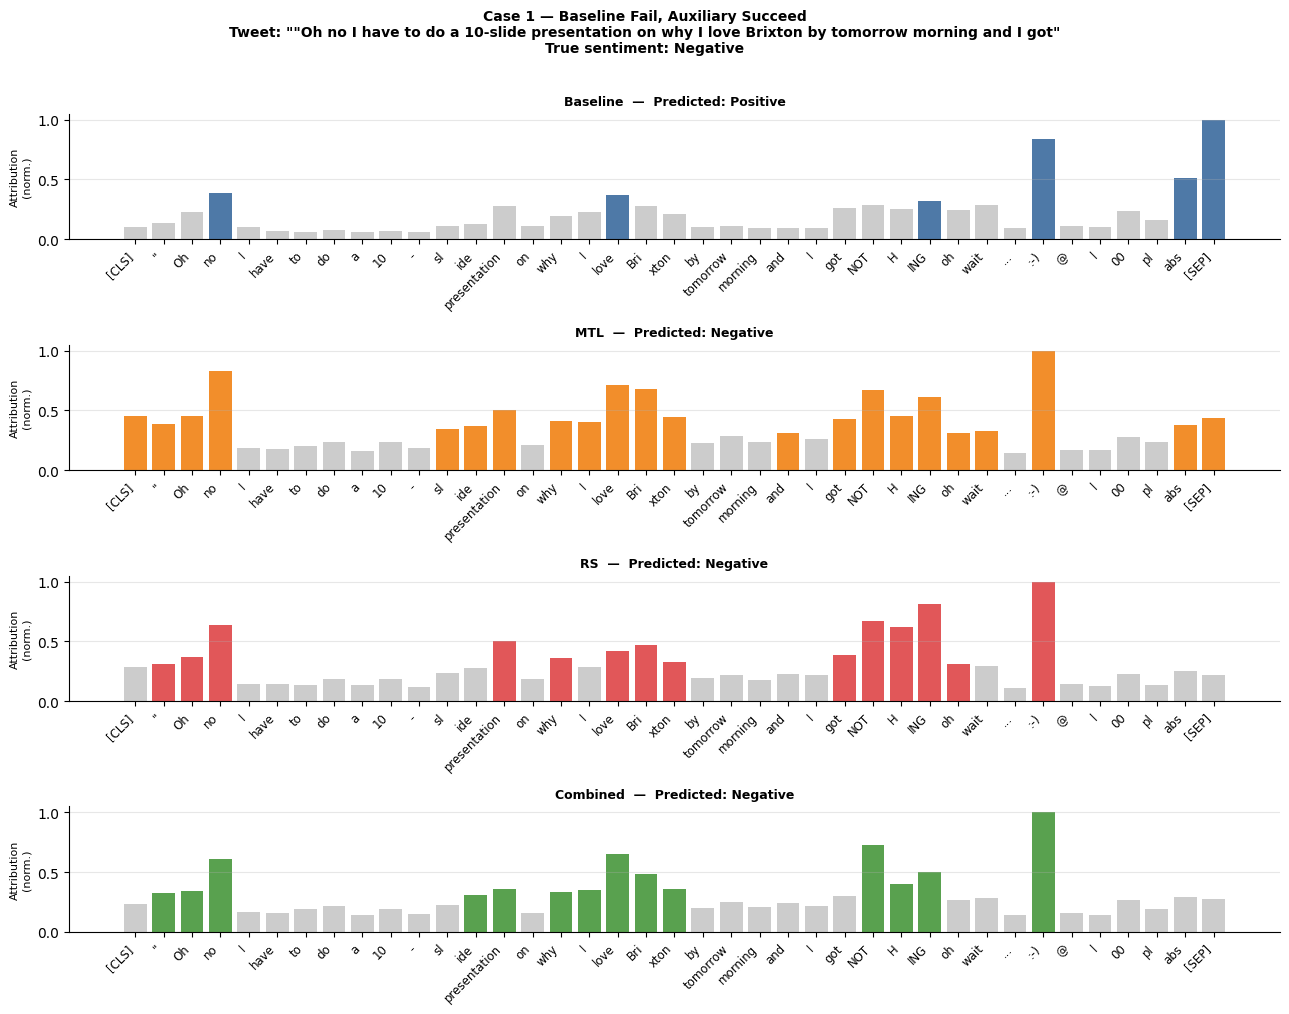


Generating Plot: Case 2 — Rationale Rescue (Combined & RS Succeed, MTL & Baseline Fail)
  Baseline: ['"', '[CLS]', 'sleep', 'Who', 'like']
  MTL: ['[SEP]', '"', 'sleep', 'Who', '[CLS]']
  RS: ['sleep', '"', 'needs', 'Who', 'like']
  Combined: ['sleep', 'not', '"', 'Who', '[CLS]']


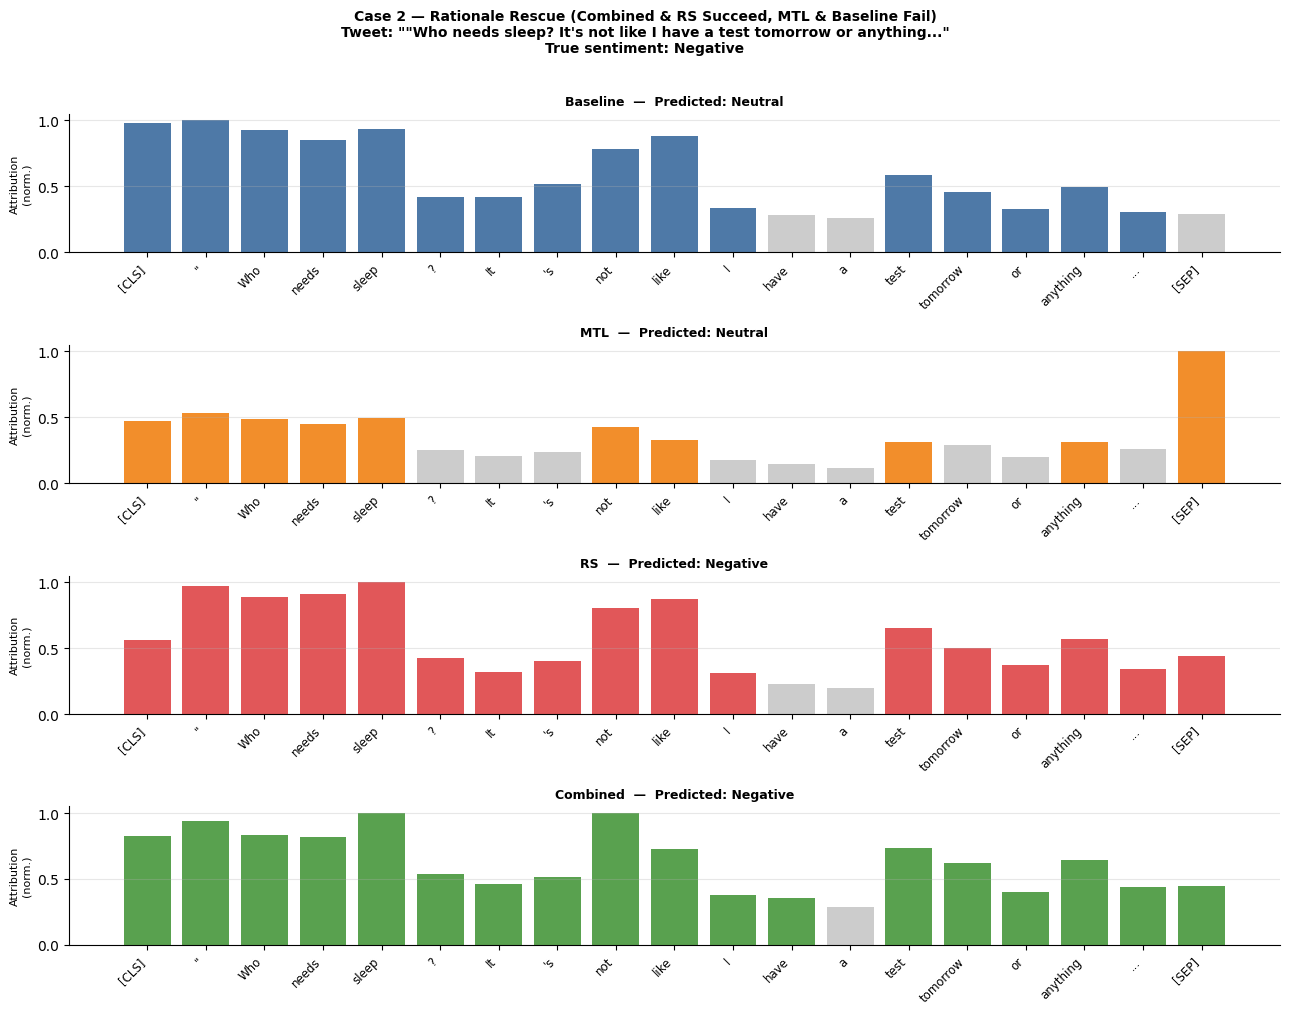


Generating Plot: Case 3 — All Model Fail (Current Limits)
  Baseline: ['Great', 'sense', 'Sched', 'waiting', 'Thanks']
  MTL: ['sense', 'Sched', 'Great', 'wall', 'waiting']
  RS: ['Great', 'sense', 'Sched', 'Thanks', 'Sat']
  Combined: ['Great', 'sense', 'Sched', 'Thanks', '[SEP]']


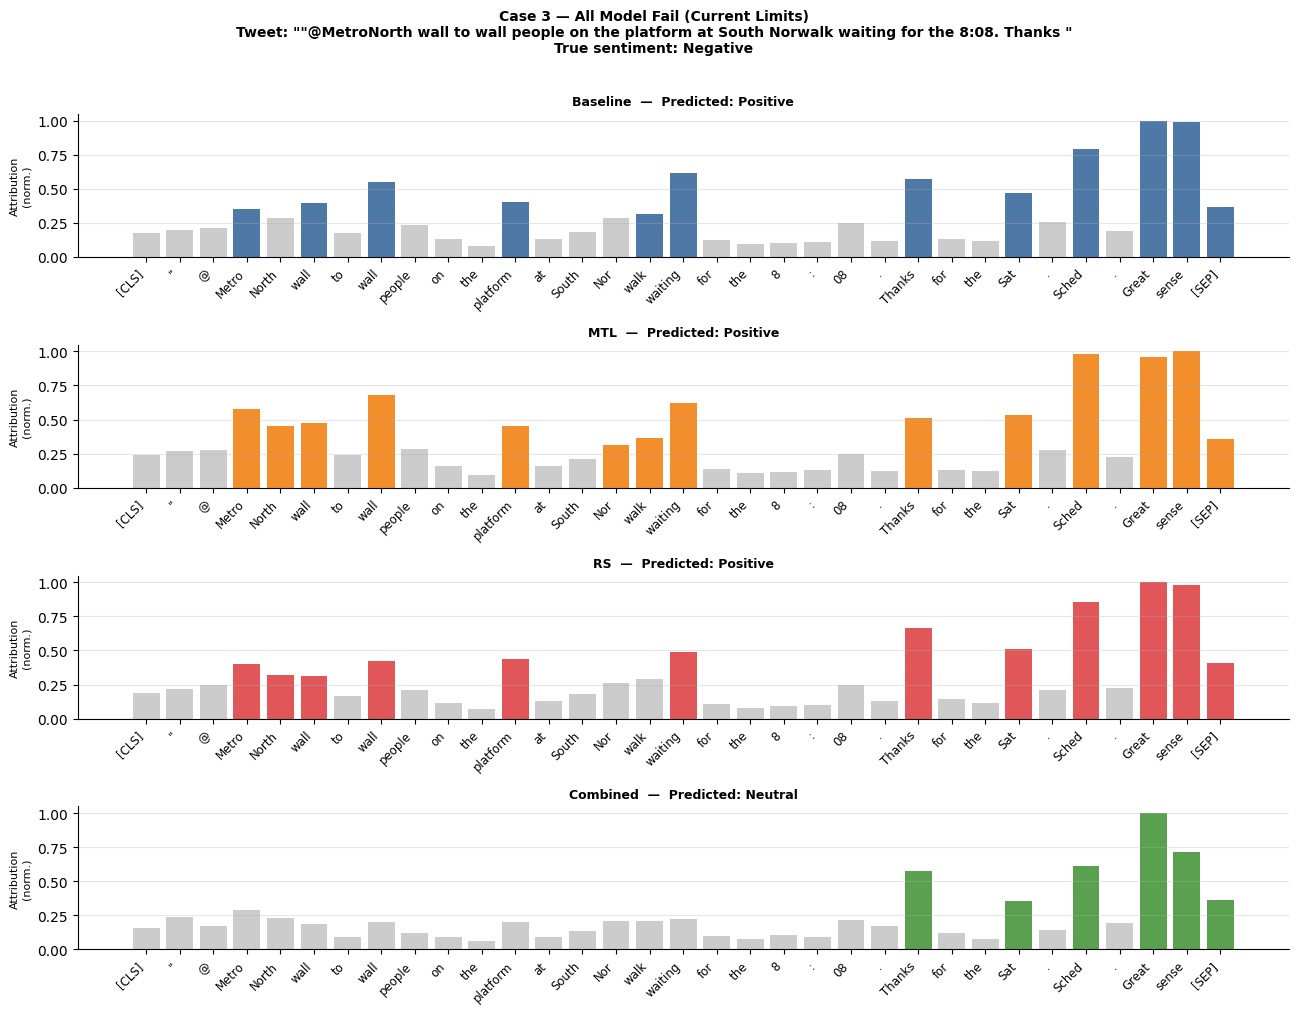

In [62]:
# Run IG for each case
ig_cases = []
if case1 is not None:
    ig_cases.append((case1, 'Case 1 — Baseline Fail, Auxiliary Succeed'))
if case2 is not None:
    ig_cases.append((case2, 'Case 2 — Rationale Rescue (Combined & RS Succeed, MTL & Baseline Fail)'))
if case3 is not None:
    ig_cases.append((case3, 'Case 3 — All Model Fail (Current Limits)'))

# Run the plotting loop as defined in your code
for case_row, case_title in ig_cases:
    print(f'\nGenerating Plot: {case_title}')
    plot_ig_subplots(case_row, case_title, pred_col_map)

## 5.  Auxiliary Task Analysis

### Sarcasm detection analysis

In [21]:
from scipy.stats import fisher_exact

print(f"{'Model':<10} | {'Sarcasm Detect':<16} | {'Acc (Det)':<10} | {'Acc (Miss)':<10} | {'p-value'}")
print("-" * 75)

for model_name in ['MTL', 'Combined']:
    all_det_rates, all_acc_det, all_acc_miss, all_p_vals = [], [], [], []

    for seed in [7, 42, 100]:
        df = pd.read_csv(f'{PRED_DIR}/{model_name.lower()}_seed{seed}_gold.csv')
        
        is_detected = df['pred_sarcasm'] == 1
        is_missed = ~is_detected
        correct = df['label'] == df['pred']
        
        # 1. Collect standard metrics
        all_det_rates.append(is_detected.mean())
        all_acc_det.append(df[is_detected][['label', 'pred']].apply(lambda x: x[0] == x[1], axis=1).mean())
        all_acc_miss.append(df[is_missed][['label', 'pred']].apply(lambda x: x[0] == x[1], axis=1).mean())
        
        # 2. Fisher's Exact Test (Contingency Table)
        # [[Correct & Det, Wrong & Det], 
        #  [Correct & Miss, Wrong & Miss]]
        table = [
            [(is_detected & correct).sum(), (is_detected & ~correct).sum()],
            [(is_missed & correct).sum(),   (is_missed & ~correct).sum()]
        ]
        _, p_val = fisher_exact(table)
        all_p_vals.append(p_val)

    # Calculate medians for the final report
    med_p = np.median(all_p_vals)
    sig_star = "**" if med_p < 0.01 else "*" if med_p < 0.05 else ""

    print(f"{model_name:<10} | {np.median(all_det_rates):<16.1%} | "
          f"{np.median(all_acc_det):<10.3f} | {np.median(all_acc_miss):<10.3f} | "
          f"{med_p:.4f} {sig_star}")


Model      | Sarcasm Detect   | Acc (Det)  | Acc (Miss) | p-value
---------------------------------------------------------------------------
MTL        | 41.9%            | 0.537      | 0.720      | 0.0743 
Combined   | 47.7%            | 0.585      | 0.872      | 0.0089 **


### CKA representation similarity

In [53]:
# ANALYSIS: CKA REPRESENTATION SIMILARITY TO BASELINE
def get_pooled_representations(model, model_name, texts, batch_size=32):
    """
    Extracts the mean-pooled hidden states from the RoBERTa backbone.
    """
    all_reps = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Representations ({model_name})"):
            batch = texts[i : i + batch_size]
            inputs = tokenizer(
                batch, 
                return_tensors='pt', 
                truncation=True, 
                padding=True, 
                max_length=128 
            ).to(DEVICE)
            
            # Access the RoBERTa backbone
            outputs = model.roberta(inputs['input_ids'], inputs['attention_mask'])
            last_hidden = outputs.last_hidden_state # [batch, seq_len, 768]
            
            # Mean Pooling
            mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
            sum_embeddings = torch.sum(last_hidden * mask, 1)
            sum_mask = torch.clamp(mask.sum(1), min=1e-9)
            pooled = sum_embeddings / sum_mask
            
            all_reps.append(pooled.cpu().numpy())
            
    return np.vstack(all_reps)
def linear_cka(X, Y):
    """Linear CKA between two representation matrices X, Y."""
    X = X - X.mean(0); Y = Y - Y.mean(0)
    XTX = X.T @ X; YTY = Y.T @ Y; XTY = X.T @ Y
    hsic_xy = np.linalg.norm(XTY, 'fro') ** 2
    hsic_xx = np.linalg.norm(XTX, 'fro') ** 2
    hsic_yy = np.linalg.norm(YTY, 'fro') ** 2
    return hsic_xy / (np.sqrt(hsic_xx) * np.sqrt(hsic_yy)) if hsic_xx > 0 and hsic_yy > 0 else 0.0

print("CKA ANALYSIS: REPRESENTATION DIVERGENCE FROM BASELINE")
print("="*60)

# Use the Golden Set (OOD) to measure where the models differ most
gold_texts = df_gold_raw['text'].tolist()
cka_results = {name: [] for name in ['MTL', 'RS', 'Combined']}

for seed in SEEDS:
    print(f"Processing Seed {seed}...")
    base_model = load_model('Baseline', seed)
    base_reps = get_pooled_representations(base_model, 'Baseline', gold_texts)
    del base_model; torch.cuda.empty_cache()

    for model_name in ['MTL', 'RS', 'Combined']:
        model = load_model(model_name, seed)
        reps = get_pooled_representations(model, model_name, gold_texts)
        cka_val = linear_cka(base_reps, reps)
        cka_results[model_name].append(cka_val)
        del model; torch.cuda.empty_cache()

# Print Summary
print(f"\n{'Model':<12} | {'Mean CKA':<10} | {'Std':<8} | Interpretation")
print("-" * 65)
for name in ['MTL', 'RS', 'Combined']:
    m, s = np.mean(cka_results[name]), np.std(cka_results[name])
    interp = "Strong Restructuring" if m < 0.75 else "Moderate Restructuring" if m < 0.85 else "Low Divergence"
    print(f"{name:<12} | {m:.4f}     | {s:.4f}   | {interp}")

CKA ANALYSIS: REPRESENTATION DIVERGENCE FROM BASELINE
Processing Seed 7...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Representations (Baseline):   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Representations (RS):   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Representations (Combined):   0%|          | 0/3 [00:00<?, ?it/s]


Model        | Mean CKA   | Std      | Interpretation
-----------------------------------------------------------------
MTL          | 0.9038     | 0.0243   | Low Divergence
RS           | 0.8282     | 0.0279   | Moderate Restructuring
Combined     | 0.7080     | 0.0765   | Strong Restructuring


### t-SNE visualization

t-SNE ANALYSIS: VISUALIZING PRAGMATIC SEPARATION


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Representations (Baseline):   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Representations (RS):   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.dense.bias           | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Representations (Combined):   0%|          | 0/3 [00:00<?, ?it/s]

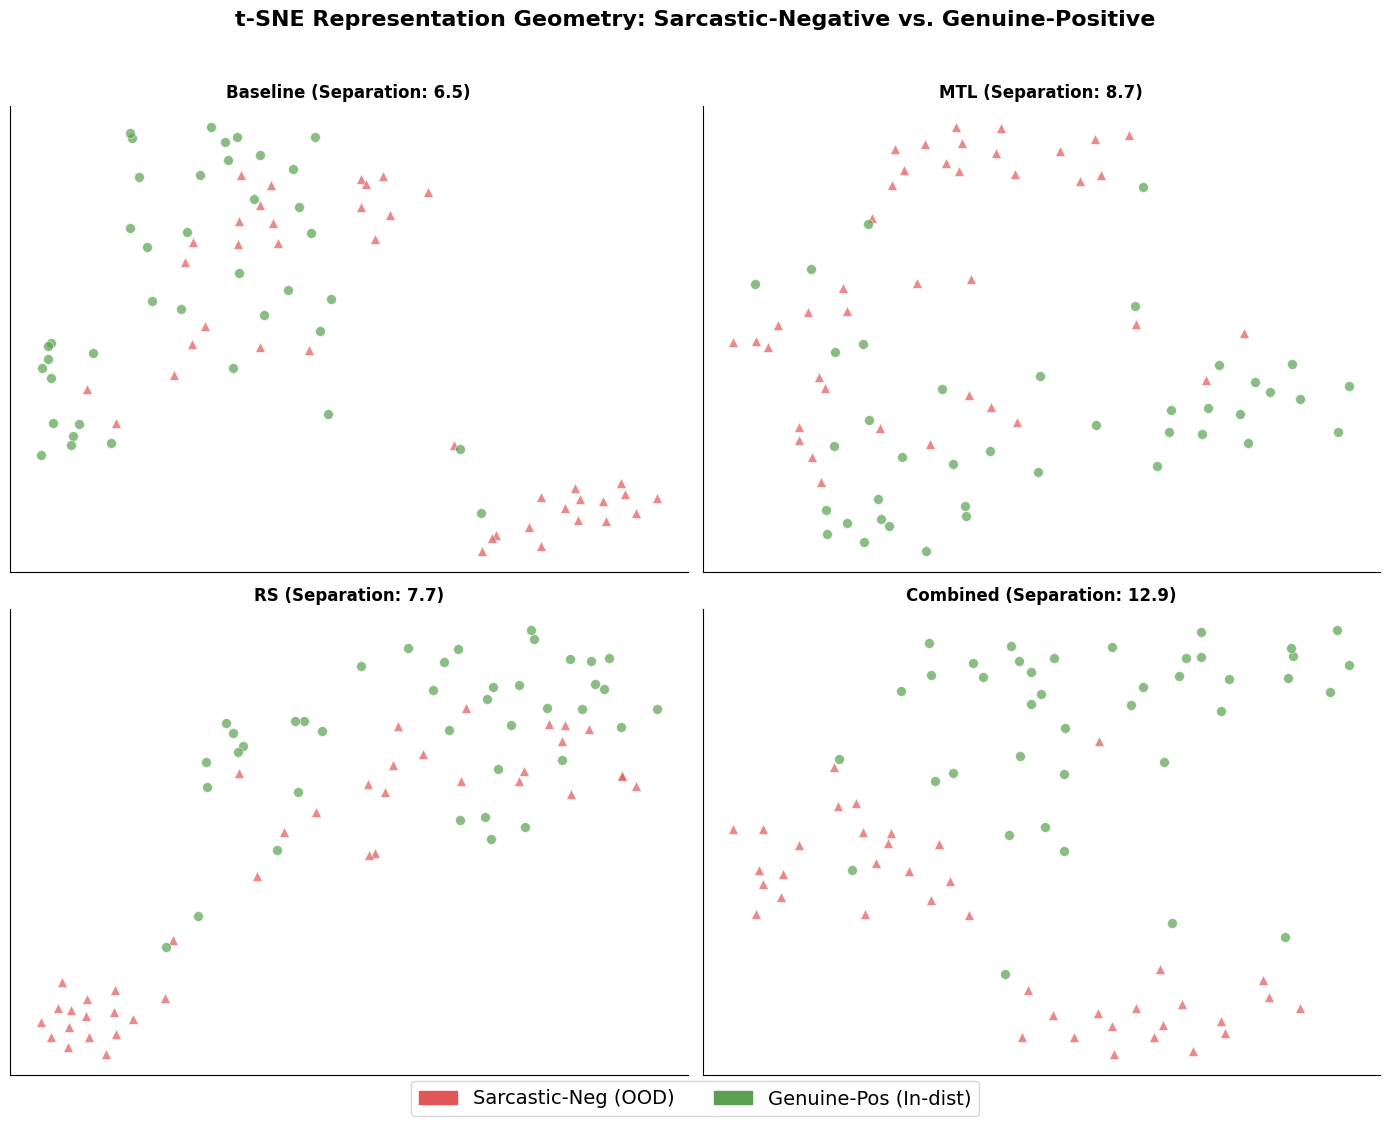

In [52]:
# ANALYSIS: t-SNE GEOMETRY (PRAGMATIC SEPARATION)
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

print("t-SNE ANALYSIS: VISUALIZING PRAGMATIC SEPARATION")

# Create a focused dataset of Sarcastic-Neg vs Genuine-Pos
df_sarc_neg_viz = df_gold_raw[df_gold_raw['label'] == 0].copy()
df_sarc_neg_viz['group'] = 'Sarcastic-Neg (OOD)'

# Sample equal amount of positive sentiment from test set
n_sarcastic = len(df_sarc_neg_viz)
df_gen_pos_viz = df_test_raw[df_test_raw['label'] == 2].sample(n=n_sarcastic, random_state=42).copy()
df_gen_pos_viz['group'] = 'Genuine-Pos (In-dist)'

df_viz = pd.concat([df_sarc_neg_viz, df_gen_pos_viz], ignore_index=True)
viz_texts = df_viz['text'].tolist()

group_style = {
    'Sarcastic-Neg (OOD)':  {'c': '#e15759', 'm': '^'}, # Red Triangles
    'Genuine-Pos (In-dist)': {'c': '#59a14f', 'm': 'o'}  # Green Circles
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, model_name in zip(axes.flat, MODEL_ORDER):
    # Use Seed 42 for a representative visualization
    model = load_model(model_name, seed=42)
    reps = get_pooled_representations(model, model_name, viz_texts)
    del model; torch.cuda.empty_cache()

    tsne = TSNE(n_components=2, random_state=42, perplexity=15)
    emb = tsne.fit_transform(reps)

    for g, style in group_style.items():
        mask = df_viz['group'] == g
        ax.scatter(emb[mask, 0], emb[mask, 1], c=style['c'], marker=style['m'], 
                   alpha=0.7, s=50, label=g, edgecolors='white', linewidths=0.5)

    # Calculate distance between centroids to quantify separation
    dist = np.linalg.norm(emb[df_viz['group']=='Sarcastic-Neg (OOD)'].mean(0) - 
                          emb[df_viz['group']=='Genuine-Pos (In-dist)'].mean(0))
    
    ax.set_title(f'{model_name} (Separation: {dist:.1f})', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Add shared legend and save
handles = [mpatches.Patch(color=v['c'], label=k) for k, v in group_style.items()]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 0.02))
plt.suptitle('t-SNE Representation Geometry: Sarcastic-Negative vs. Genuine-Positive', 
             fontsize=16, fontweight='bold', y=0.95)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('../outputs/figures/tsne_pragmatic_separation.png', dpi=300, bbox_inches='tight')
plt.show()